In [1]:
import numpy as np
from compartments import CompartmentPatchArray, SEIRV_patch_stepper

In [2]:
NUMPATCHES = 2
NUMCOMPARTMENTS = 5

init_state = np.array([[10000, 3, 2, 0, 0], [10000, 3, 2, 0, 0]], dtype = float)
seirv_state = CompartmentPatchArray(
    state= init_state,
    num_compartments=NUMCOMPARTMENTS,
    num_patches=NUMPATCHES,
    iter_num=0
)

vaccinations = np.array((0,0))
VACCINE_EFFICACY = 0
WEIBULL_WANING_SHAPE = 0
WEIBULL_WANING_SCALE = 0
params_stepper = {
        'gamma': 1/5,
        'alpha': 1/5.8,
        'vaccination_14_days_prior': vaccinations,
        'vaccine_efficacy': VACCINE_EFFICACY,
        'waning_weibull_shape': WEIBULL_WANING_SHAPE,
        'waning_weibull_scale': WEIBULL_WANING_SCALE
        }

In [3]:
patchstates = []
STEPS = 100
betas_patches = np.array((1, 1))
network_matrix = np.eye(2)
for i in range(STEPS):
    step = SEIRV_patch_stepper(
        compartment_patch_array=seirv_state,
        network_matrix=network_matrix,
        betas_patches=betas_patches,
        **params_stepper
    )
    patchstates.append(seirv_state.get_copy_of_the_state())
    seirv_state.update_state(seirv_state.state + step)
    seirv_state.incr_iter_num()


In [4]:
patchstates = np.array(patchstates)
patchstates.shape

(100, 2, 5)

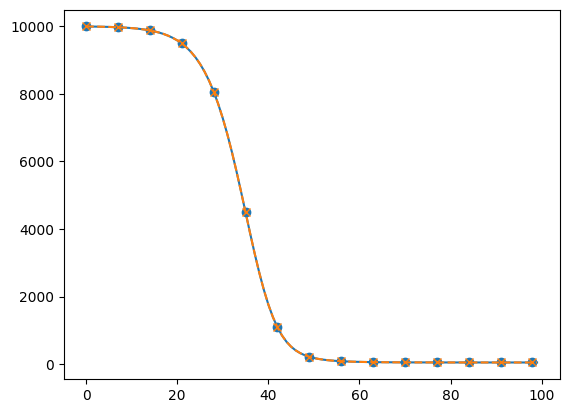

In [ ]:
import matplotlib.pyplot as plt
plt.plot(patchstates[:,0, 0], marker = 'o', markevery = 7, label = 'Patch-1')
plt.plot(patchstates[:,1, 0], marker = 'x', linestyle = 'dashed', markevery = 7, label = 'Patch-2')

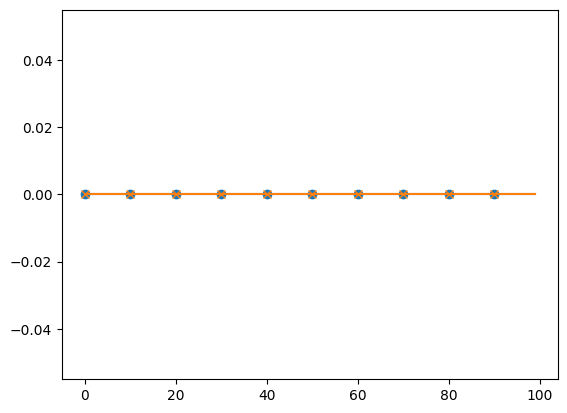

In [6]:
plt.plot(patchstates[:,0, -1], marker = 'o', markevery = 10)
plt.plot(patchstates[:,1, -1], marker = 'x', markevery = 10)